<a href="https://colab.research.google.com/github/A-ros1076/BUS118s/blob/Dev/InventoryReplenishmentAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inventory Replenishment Agent
**BUS118s | Group Exercise: Agentic AI in Supply Chain**

This notebook implements an autonomous inventory replenishment agent that:
1. Generates and loads supply chain data (sales, inventory, parameters) for 3 SKUs
2. Forecasts daily demand using Exponentially Weighted Moving Average (EWMA)
3. Computes safety stock from forecast error and target service level
4. Runs a day-by-day simulation where the agent decides to place purchase orders or wait
5. Evaluates performance (stockouts, fill rate, total cost) against a naive baseline

---

## 1. Setup and Imports

In [1]:
# --------------------------------------------------------------------------
# Core libraries for data manipulation, math, and visualization
# --------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Reproducibility seed
rng = np.random.default_rng(42)

print('All imports successful.')

All imports successful.


## 2. Data Generation

We create three CSV datasets inline (no external files needed). The rubric asks for
1 to 3 SKUs and 60 to 120 days of sales. We use **3 SKUs** over **90 days** with
distinct demand profiles:

| SKU | Profile | Description |
|-----|---------|-------------|
| SKU_A | Steady | Stable daily demand around 20 units, low variance |
| SKU_B | Seasonal | Weekly cycle with higher weekend demand |
| SKU_C | Spiky | Low baseline with random promotional spikes |

In [2]:
# --------------------------------------------------------------------------
# 2a. Generate sales.csv: daily demand for 3 SKUs over 90 days
# --------------------------------------------------------------------------
NUM_DAYS = 90
START_DATE = pd.Timestamp('2024-07-01')
dates = pd.date_range(START_DATE, periods=NUM_DAYS, freq='D')

sales_records = []

for d_idx, date in enumerate(dates):
    # SKU_A: steady demand, mean ~20, std ~3
    qty_a = max(0, int(round(rng.normal(20, 3))))

    # SKU_B: seasonal, higher on weekends (day 5=Sat, 6=Sun)
    base_b = 15 + 5 * np.sin(2 * np.pi * date.dayofweek / 7)
    qty_b = max(0, int(round(rng.normal(base_b, 4))))

    # SKU_C: spiky, low baseline ~8 with random promo spikes
    spike = rng.integers(15, 35) if rng.random() < 0.1 else 0  # ~10% chance of spike
    qty_c = max(0, int(round(rng.normal(8, 2))) + spike)

    sales_records.append({'date': date.strftime('%Y-%m-%d'), 'sku': 'SKU_A', 'qty_sold': qty_a})
    sales_records.append({'date': date.strftime('%Y-%m-%d'), 'sku': 'SKU_B', 'qty_sold': qty_b})
    sales_records.append({'date': date.strftime('%Y-%m-%d'), 'sku': 'SKU_C', 'qty_sold': qty_c})

sales_df = pd.DataFrame(sales_records)
print(f'sales.csv: {len(sales_df)} rows, {sales_df["sku"].nunique()} SKUs, {NUM_DAYS} days')
sales_df.head(6)

sales.csv: 270 rows, 3 SKUs, 90 days


,date,sku,qty_sold
0,2024-07-01,SKU_A,21
1,2024-07-01,SKU_B,11
2,2024-07-01,SKU_C,10
3,2024-07-02,SKU_A,14
4,2024-07-02,SKU_B,14
5,2024-07-02,SKU_C,7


In [3]:
# --------------------------------------------------------------------------
# 2b. Generate inventory.csv: opening stock per SKU
# We set opening stock to roughly 2 weeks of average demand per SKU.
# --------------------------------------------------------------------------
inventory_df = pd.DataFrame([
    {'sku': 'SKU_A', 'opening_stock': 300},   # ~20/day * 15 days
    {'sku': 'SKU_B', 'opening_stock': 250},   # ~15/day * 17 days
    {'sku': 'SKU_C', 'opening_stock': 150},   # ~10/day * 15 days
])
print('inventory.csv:')
inventory_df

inventory.csv:


,sku,opening_stock
0,SKU_A,300
1,SKU_B,250
2,SKU_C,150


In [4]:
# --------------------------------------------------------------------------
# 2c. Generate params.csv: policy and cost inputs per SKU
#
# Columns:
#   unit_cost           - cost per unit purchased
#   holding_cost_per_day- daily cost to hold one unit in inventory
#   stockout_cost       - penalty per unit of unmet demand
#   lead_time_days      - days between placing and receiving a PO
#   min_order_qty       - minimum units per purchase order
#   service_level       - target fill probability (e.g. 0.95 = 95%)
# --------------------------------------------------------------------------
params_df = pd.DataFrame([
    {'sku': 'SKU_A', 'unit_cost': 10.0, 'holding_cost_per_day': 0.05,
     'stockout_cost': 5.0, 'lead_time_days': 5, 'min_order_qty': 50, 'service_level': 0.95},
    {'sku': 'SKU_B', 'unit_cost': 25.0, 'holding_cost_per_day': 0.10,
     'stockout_cost': 8.0, 'lead_time_days': 7, 'min_order_qty': 30, 'service_level': 0.90},
    {'sku': 'SKU_C', 'unit_cost': 15.0, 'holding_cost_per_day': 0.08,
     'stockout_cost': 12.0, 'lead_time_days': 3, 'min_order_qty': 20, 'service_level': 0.95},
])
print('params.csv:')
params_df

params.csv:


,sku,unit_cost,holding_cost_per_day,stockout_cost,lead_time_days,min_order_qty,service_level
0,SKU_A,10.0,0.05,5.0,5,50,0.95
1,SKU_B,25.0,0.10,8.0,7,30,0.90
2,SKU_C,15.0,0.08,12.0,3,20,0.95


## 3. Data Loading and Aggregation

**Rubric: Data Handling (2 pts)** - Loads sales, inventory, and params. Aggregates demand per SKU per day.

In [5]:
# --------------------------------------------------------------------------
# 3a. Load and parse dates
# In a production setting these would be pd.read_csv() calls.
# Here we use the DataFrames created above.
# --------------------------------------------------------------------------
sales = sales_df.copy()
sales['date'] = pd.to_datetime(sales['date'])

inventory = inventory_df.copy()
params = params_df.copy()

# --------------------------------------------------------------------------
# 3b. Aggregate: total daily demand per SKU
# (Already one row per SKU per day, but groupby ensures correctness
# if there were multiple entries per day.)
# --------------------------------------------------------------------------
daily_demand = (
    sales
    .groupby(['date', 'sku'])['qty_sold']
    .sum()
    .reset_index()
    .rename(columns={'qty_sold': 'demand'})
)

print(f'Aggregated demand: {len(daily_demand)} rows')
print(f'SKUs: {daily_demand["sku"].unique().tolist()}')
print(f'Date range: {daily_demand["date"].min().date()} to {daily_demand["date"].max().date()}')
daily_demand.head(6)

Aggregated demand: 270 rows
SKUs: ['SKU_A', 'SKU_B', 'SKU_C']
Date range: 2024-07-01 to 2024-09-28


,date,sku,demand
0,2024-07-01,SKU_A,21
1,2024-07-01,SKU_B,11
2,2024-07-01,SKU_C,10
3,2024-07-02,SKU_A,14
4,2024-07-02,SKU_B,14
5,2024-07-02,SKU_C,7


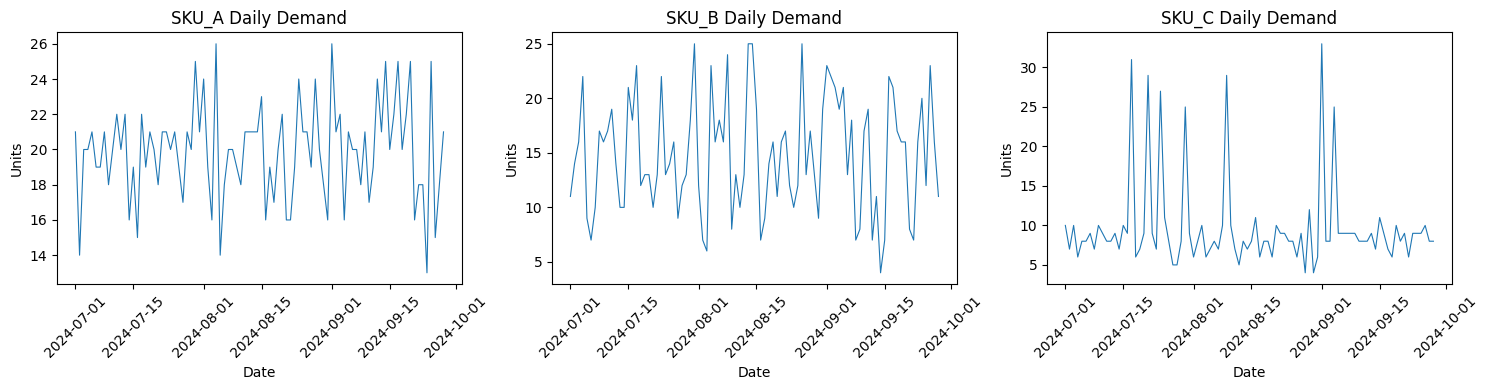

In [6]:
# --------------------------------------------------------------------------
# 3c. Quick visualization of demand profiles per SKU
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, sku in zip(axes, ['SKU_A', 'SKU_B', 'SKU_C']):
    sku_data = daily_demand[daily_demand['sku'] == sku]
    ax.plot(sku_data['date'], sku_data['demand'], linewidth=0.8)
    ax.set_title(f'{sku} Daily Demand')
    ax.set_xlabel('Date')
    ax.set_ylabel('Units')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. EWMA Demand Forecasting

**Rubric: Forecasting (2 pts)** - Implements EWMA forecast that updates daily.

We use Exponentially Weighted Moving Average (EWMA) to forecast next-day demand.
The EWMA forecast updates each day as:

$$\hat{d}_{t+1} = \alpha \cdot d_t + (1 - \alpha) \cdot \hat{d}_t$$

where $\alpha$ is the smoothing factor (higher = more responsive to recent data).

In [7]:
# --------------------------------------------------------------------------
# 4a. EWMA forecasting function
#
# Parameters:
#   demand_series - array of historical daily demand values
#   alpha         - smoothing factor (0 < alpha <= 1), higher = more reactive
#
# Returns:
#   forecasts     - array of one-step-ahead forecasts (same length as input)
#   errors        - array of forecast errors (actual - forecast)
# --------------------------------------------------------------------------
def ewma_forecast(demand_series, alpha=0.3):
    """Compute daily EWMA forecasts and forecast errors."""
    n = len(demand_series)
    forecasts = np.zeros(n)
    errors = np.zeros(n)

    # Initialize: first forecast = first actual demand
    forecasts[0] = demand_series[0]
    errors[0] = 0.0

    for t in range(1, n):
        # EWMA update: blend yesterday's actual with yesterday's forecast
        forecasts[t] = alpha * demand_series[t - 1] + (1 - alpha) * forecasts[t - 1]
        errors[t] = demand_series[t] - forecasts[t]

    return forecasts, errors

In [8]:
# --------------------------------------------------------------------------
# 4b. Train/test split and run EWMA per SKU
#
# We use the first 30 days as a warm-up period to establish the forecast,
# then simulate over the remaining 60 days.
# --------------------------------------------------------------------------
WARMUP_DAYS = 30  # days used to warm up the EWMA forecast
ALPHA = 0.3       # smoothing parameter (adjustable)

# Store forecast data per SKU for use in the simulation
sku_forecast_data = {}

for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    sku_demand = daily_demand[daily_demand['sku'] == sku].sort_values('date').reset_index(drop=True)
    demand_vals = sku_demand['demand'].values

    # Run EWMA over ALL days (warmup + simulation)
    forecasts, errors = ewma_forecast(demand_vals, alpha=ALPHA)

    # Compute forecast error std from warmup period (used for safety stock)
    warmup_errors = errors[:WARMUP_DAYS]
    forecast_error_std = np.std(warmup_errors, ddof=1)

    sku_forecast_data[sku] = {
        'dates': sku_demand['date'].values,
        'actuals': demand_vals,
        'forecasts': forecasts,
        'errors': errors,
        'forecast_error_std': forecast_error_std,
    }

    mae = np.mean(np.abs(errors[WARMUP_DAYS:]))
    print(f'{sku}: Forecast Error Std (warmup) = {forecast_error_std:.2f}, '
          f'MAE (sim period) = {mae:.2f}')

SKU_A: Forecast Error Std (warmup) = 2.50, MAE (sim period) = 2.60
SKU_B: Forecast Error Std (warmup) = 4.80, MAE (sim period) = 5.08
SKU_C: Forecast Error Std (warmup) = 7.79, MAE (sim period) = 3.16


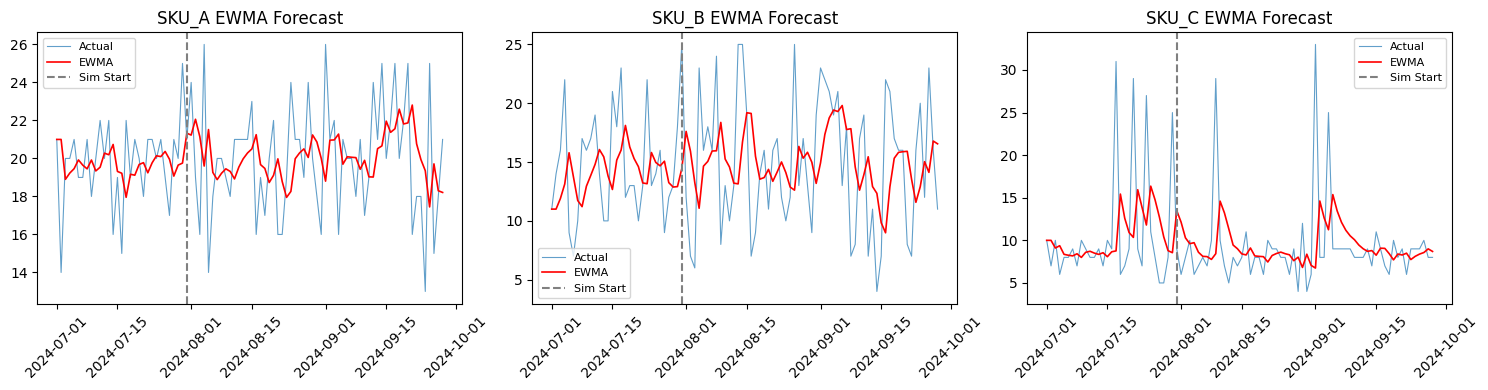

In [9]:
# --------------------------------------------------------------------------
# 4c. Visualize EWMA forecast vs actuals for each SKU
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sku in zip(axes, ['SKU_A', 'SKU_B', 'SKU_C']):
    fd = sku_forecast_data[sku]
    ax.plot(fd['dates'], fd['actuals'], label='Actual', alpha=0.7, linewidth=0.8)
    ax.plot(fd['dates'], fd['forecasts'], label='EWMA', linewidth=1.2, color='red')
    ax.axvline(fd['dates'][WARMUP_DAYS], color='gray', linestyle='--', label='Sim Start')
    ax.set_title(f'{sku} EWMA Forecast')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Safety Stock Computation

**Rubric: Safety Stock & Reorder Logic (2 pts)** - Computes safety stock using forecast error and service_level.

Safety stock buffers against demand uncertainty during lead time:

$$SS = z_{\text{CSL}} \times \sigma_e \times \sqrt{L}$$

where $z_{\text{CSL}}$ is the z-score for the target service level, $\sigma_e$ is the
forecast error standard deviation, and $L$ is the lead time in days.

In [10]:
# --------------------------------------------------------------------------
# 5a. Compute safety stock and reorder point per SKU
# --------------------------------------------------------------------------
def compute_safety_stock(forecast_error_std, service_level, lead_time):
    """Compute safety stock from forecast error std, service level, and lead time."""
    z = norm.ppf(service_level)  # z-score for target service level
    safety_stock = z * forecast_error_std * np.sqrt(lead_time)
    return safety_stock, z

# Build a config dictionary per SKU that merges params + forecast data
sku_config = {}
for _, row in params.iterrows():
    sku = row['sku']
    fd = sku_forecast_data[sku]
    ss, z = compute_safety_stock(
        fd['forecast_error_std'], row['service_level'], row['lead_time_days']
    )
    sku_config[sku] = {
        'unit_cost': row['unit_cost'],
        'holding_cost': row['holding_cost_per_day'],
        'stockout_cost': row['stockout_cost'],
        'lead_time': int(row['lead_time_days']),
        'min_order_qty': int(row['min_order_qty']),
        'service_level': row['service_level'],
        'safety_stock': ss,
        'z_score': z,
        'forecast_error_std': fd['forecast_error_std'],
        'opening_stock': int(inventory[inventory['sku'] == sku]['opening_stock'].values[0]),
    }
    print(f'{sku}: z={z:.2f}, sigma_e={fd["forecast_error_std"]:.2f}, '
          f'L={int(row["lead_time_days"])}, Safety Stock={ss:.1f} units')

SKU_A: z=1.64, sigma_e=2.50, L=5, Safety Stock=9.2 units
SKU_B: z=1.28, sigma_e=4.80, L=7, Safety Stock=16.3 units
SKU_C: z=1.64, sigma_e=7.79, L=3, Safety Stock=22.2 units


## 6. Inventory Simulation Engine

**Rubric: Simulation & Logging (2 pts)** - Simulates day-by-day inventory,
receives POs after lead time, prints clear daily agent log with rationale.

In [11]:
# --------------------------------------------------------------------------
# 6a. Simulation class: tracks on-hand inventory, pipeline orders, costs
# --------------------------------------------------------------------------
class InventorySimulator:
    """
    Simulates day-by-day inventory for a single SKU.
    Handles:
      - Receiving arriving POs after lead time
      - Satisfying demand (unfilled demand becomes lost sales)
      - Tracking holding cost, stockout cost, and order cost
    """
    def __init__(self, opening_stock, lead_time, holding_cost, stockout_cost, unit_cost):
        self.on_hand = opening_stock
        self.lead_time = lead_time
        self.holding_cost_rate = holding_cost
        self.stockout_cost_rate = stockout_cost
        self.unit_cost = unit_cost

        # Pipeline: queue of (arrival_day, quantity) tuples
        self.pipeline = deque()

        # Cumulative cost trackers
        self.total_holding_cost = 0.0
        self.total_stockout_cost = 0.0
        self.total_order_cost = 0.0

        # Performance trackers
        self.total_demand = 0
        self.total_fulfilled = 0
        self.stockout_days = 0

        # Daily log
        self.log = []

    def step(self, day_index, date, demand, order_qty=0, rationale=''):
        """
        Process one day: receive arrivals, fulfill demand, place order, compute costs.

        Parameters:
            day_index  - integer day counter (used for lead time tracking)
            date       - actual calendar date
            demand     - units demanded today
            order_qty  - units to order (0 = no order)
            rationale  - text explanation of the agent's decision
        """
        # --- 1. Receive any arriving orders ---
        arrived = 0
        while self.pipeline and self.pipeline[0][0] <= day_index:
            _, qty = self.pipeline.popleft()
            arrived += qty
        self.on_hand += arrived

        # --- 2. Fulfill demand ---
        fulfilled = min(self.on_hand, demand)
        unfulfilled = demand - fulfilled
        self.on_hand -= fulfilled

        self.total_demand += demand
        self.total_fulfilled += fulfilled
        if unfulfilled > 0:
            self.stockout_days += 1

        # --- 3. Place order (added to pipeline with arrival after lead time) ---
        if order_qty > 0:
            arrival_day = day_index + self.lead_time
            self.pipeline.append((arrival_day, order_qty))
            self.total_order_cost += order_qty * self.unit_cost

        # --- 4. Compute daily costs ---
        daily_holding = self.holding_cost_rate * max(self.on_hand, 0)
        daily_stockout = self.stockout_cost_rate * unfulfilled
        self.total_holding_cost += daily_holding
        self.total_stockout_cost += daily_stockout

        # --- 5. Log this day ---
        pipeline_total = sum(qty for _, qty in self.pipeline)
        self.log.append({
            'date': date,
            'demand': demand,
            'arrived': arrived,
            'fulfilled': fulfilled,
            'unfulfilled': unfulfilled,
            'on_hand': self.on_hand,
            'pipeline': pipeline_total,
            'order_placed': order_qty,
            'holding_cost': daily_holding,
            'stockout_cost': daily_stockout,
            'rationale': rationale,
        })

    def get_kpis(self):
        """Return summary KPIs for this simulation run."""
        fill_rate = self.total_fulfilled / self.total_demand if self.total_demand > 0 else 1.0
        return {
            'fill_rate': round(fill_rate, 4),
            'stockout_days': self.stockout_days,
            'total_holding_cost': round(self.total_holding_cost, 2),
            'total_stockout_cost': round(self.total_stockout_cost, 2),
            'total_order_cost': round(self.total_order_cost, 2),
            'total_cost': round(self.total_holding_cost + self.total_stockout_cost + self.total_order_cost, 2),
        }

## 7. Agent Tools, Memory, and Decision Loop

Following the **Plan > Act > Observe** agentic pattern, we define:

1. **Observation (`Obs`)**: The agent's view of current state (on-hand, pipeline, date)
2. **Memory (`Memory`)**: Short-term memory tracking last forecast and last action
3. **Tools**: Named functions the agent can call:
   - `tool_forecast(day_idx)` : Get EWMA forecast for next L days of demand
   - `tool_optimize(order_up_to, inv_position)` : Compute order quantity to reach target level
   - `tool_execute(sim, demand, qty, date)` : Place the order and advance the simulation
4. **Agent Loop**: Each day, the agent observes state, calls tools in sequence, and logs its rationale

This mirrors how production agentic systems structure autonomous decision-making:
the agent does not hard-code logic inline but instead selects and calls tools based on
the current observation and its goal (minimize cost while maintaining service level).

In [12]:
# --------------------------------------------------------------------------
# 7a. Observation and Memory classes (agent state management)
# --------------------------------------------------------------------------
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class Obs:
    """What the agent observes at each time step."""
    date: object           # current date
    on_hand: float         # units currently in stock
    pipeline: float        # units ordered but not yet received
    day_index: int         # simulation day counter

@dataclass
class Memory:
    """Short-term memory the agent carries between steps."""
    last_forecast: Optional[float] = None
    last_action: Optional[str] = None
    cumulative_forecast_error: float = 0.0

# --------------------------------------------------------------------------
# 7b. Agent Tools
#
# Each tool is a standalone function the agent can call.
# This separates concerns: the agent decides WHAT to do,
# the tools handle HOW to do it.
# --------------------------------------------------------------------------

def tool_forecast(day_idx, lead_time, forecasts_array, actuals_array):
    """
    Tool 1: Forecast total demand over the next lead_time days.
    Uses the current EWMA forecast value and projects it forward.
    Also returns the latest actual for memory/bias tracking.

    Parameters:
        day_idx         - current day index in the simulation
        lead_time       - number of days to forecast ahead
        forecasts_array - full array of EWMA forecasts
        actuals_array   - full array of actual demand values

    Returns:
        forecast_DL - total forecasted demand over lead time
    """
    daily_forecast = forecasts_array[day_idx]
    forecast_DL = daily_forecast * lead_time
    return forecast_DL


def tool_optimize(order_up_to, inv_position, min_order_qty, max_order):
    """
    Tool 2: Compute the order quantity needed to reach the order-up-to level.
    Applies guardrails: min order qty and max order cap.

    Parameters:
        order_up_to   - target inventory position after ordering
        inv_position  - current inventory position (on-hand + pipeline)
        min_order_qty - minimum units per purchase order
        max_order     - maximum allowed order (prevents over-ordering)

    Returns:
        qty - integer order quantity (0 if no order needed)
    """
    raw_qty = order_up_to - inv_position
    if raw_qty <= 0:
        return 0
    # Enforce minimum order quantity
    qty = max(raw_qty, min_order_qty)
    # Cap to prevent unrealistic over-ordering
    if max_order > 0:
        qty = min(qty, max_order)
    qty = int(round(qty))
    # Final check: ensure min_order_qty after rounding
    qty = max(qty, min_order_qty)
    return qty


def tool_execute(sim, day_index, date, demand, qty, rationale):
    """
    Tool 3: Execute the order by advancing the simulation one step.

    Parameters:
        sim       - InventorySimulator instance
        day_index - current day counter
        date      - calendar date
        demand    - actual demand for today
        qty       - order quantity (0 = no order)
        rationale - text explanation for the log
    """
    sim.step(day_index, date, demand, order_qty=qty, rationale=rationale)

print('Obs, Memory, and 3 agent tools defined.')

Obs, Memory, and 3 agent tools defined.


In [13]:
# --------------------------------------------------------------------------
# 7c. Replenishment Agent: Plan > Act > Observe loop
#
# Each day the agent:
#   1. OBSERVE: Build an Obs from current simulator state
#   2. PLAN:    Call tool_forecast to get lead-time demand,
#               compute ROP and order-up-to level,
#               decide whether to order or wait
#   3. ACT:     If ordering, call tool_optimize for quantity,
#               then call tool_execute to place the PO
#   4. REMEMBER: Update Memory with last forecast and action
# --------------------------------------------------------------------------

class ReplenishmentAgent:
    """Agentic inventory controller using Plan > Act > Observe pattern."""

    def __init__(self, sku_config, forecast_data):
        self.cfg = sku_config
        self.fd = forecast_data
        self.mem = Memory()

    def run_episode(self, sim, sim_start, sim_end):
        """
        Run the full agent loop from sim_start to sim_end.
        Returns the completed simulator with logs.
        """
        for day_idx in range(sim_start, sim_end):
            date = self.fd['dates'][day_idx]
            actual_demand = int(self.fd['actuals'][day_idx])

            # --- OBSERVE ---
            pipeline_qty = sum(q for _, q in sim.pipeline)
            obs = Obs(
                date=date,
                on_hand=sim.on_hand,
                pipeline=pipeline_qty,
                day_index=day_idx,
            )

            # --- PLAN ---
            # Tool 1: Get demand forecast for next L days
            forecast_DL = tool_forecast(
                day_idx, self.cfg['lead_time'],
                self.fd['forecasts'], self.fd['actuals']
            )
            self.mem.last_forecast = forecast_DL

            # Compute reorder point and order-up-to level
            rop = forecast_DL + self.cfg['safety_stock']
            order_up_to = rop + forecast_DL  # covers review period
            inv_position = obs.on_hand + obs.pipeline

            # --- DECIDE & ACT ---
            if inv_position <= rop:
                # Tool 2: Compute optimized order quantity
                max_order = 3 * forecast_DL  # guardrail: cap at 3x lead-time demand
                qty = tool_optimize(
                    order_up_to, inv_position,
                    self.cfg['min_order_qty'], max_order
                )
                rationale = (
                    f'ORDER {qty} units | '
                    f'InvPos={inv_position:.0f} <= ROP={rop:.0f} | '
                    f'ForecastDL={forecast_DL:.0f}, SS={self.cfg["safety_stock"]:.0f}, '
                    f'Target={order_up_to:.0f}'
                )
                self.mem.last_action = f'PO {qty}'
            else:
                qty = 0
                rationale = (
                    f'WAIT | InvPos={inv_position:.0f} > ROP={rop:.0f} | '
                    f'Sufficient stock through lead time'
                )
                self.mem.last_action = 'noop'

            # Tool 3: Execute the decision
            tool_execute(sim, day_idx, date, actual_demand, qty, rationale)

            # --- REMEMBER ---
            # Track cumulative forecast error for potential bias correction
            if day_idx > 0:
                prev_forecast = self.fd['forecasts'][day_idx]
                self.mem.cumulative_forecast_error += (actual_demand - prev_forecast)

        return sim

In [14]:
# --------------------------------------------------------------------------
# 7d. Run the agent for all 3 SKUs
# --------------------------------------------------------------------------
SIM_START = WARMUP_DAYS
agent_results = {}

for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    cfg = sku_config[sku]
    fd = sku_forecast_data[sku]

    sim = InventorySimulator(
        opening_stock=cfg['opening_stock'],
        lead_time=cfg['lead_time'],
        holding_cost=cfg['holding_cost'],
        stockout_cost=cfg['stockout_cost'],
        unit_cost=cfg['unit_cost'],
    )

    agent = ReplenishmentAgent(cfg, fd)
    agent.run_episode(sim, SIM_START, NUM_DAYS)

    agent_results[sku] = {
        'sim': sim,
        'kpis': sim.get_kpis(),
        'log': pd.DataFrame(sim.log),
    }
    print(f'{sku} Agent KPIs: {sim.get_kpis()}')

SKU_A Agent KPIs: {'fill_rate': 0.9908, 'stockout_days': 3, 'total_holding_cost': 217.3, 'total_stockout_cost': 55.0, 'total_order_cost': 10400.0, 'total_cost': 10672.3}
SKU_B Agent KPIs: {'fill_rate': 0.9823, 'stockout_days': 1, 'total_holding_cost': 538.0, 'total_stockout_cost': 128.0, 'total_order_cost': 19450.0, 'total_cost': 20116.0}
SKU_C Agent KPIs: {'fill_rate': 0.9781, 'stockout_days': 1, 'total_holding_cost': 223.84, 'total_stockout_cost': 144.0, 'total_order_cost': 6675.0, 'total_cost': 7042.84}


In [15]:
# --------------------------------------------------------------------------
# 7e. Print daily agent log (first 15 days per SKU for readability)
#
# Rubric requires: "Prints clear daily agent decision log with explanation"
# --------------------------------------------------------------------------
for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    print(f'\n{"="*80}')
    print(f'DAILY AGENT LOG: {sku} (first 15 days of simulation)')
    print(f'{"="*80}')
    log = agent_results[sku]['log'].head(15)
    for _, row in log.iterrows():
        date_str = pd.Timestamp(row['date']).strftime('%Y-%m-%d')
        print(f"  {date_str} | Demand={int(row['demand']):3d} | "
              f"Fulfilled={int(row['fulfilled']):3d} | "
              f"OnHand={int(row['on_hand']):4d} | "
              f"Pipeline={int(row['pipeline']):4d} | "
              f"{row['rationale']}")


DAILY AGENT LOG: SKU_A (first 15 days of simulation)
  2024-07-31 | Demand= 21 | Fulfilled= 21 | OnHand= 279 | Pipeline=   0 | WAIT | InvPos=300 > ROP=116 | Sufficient stock through lead time
  2024-08-01 | Demand= 24 | Fulfilled= 24 | OnHand= 255 | Pipeline=   0 | WAIT | InvPos=279 > ROP=115 | Sufficient stock through lead time
  2024-08-02 | Demand= 19 | Fulfilled= 19 | OnHand= 236 | Pipeline=   0 | WAIT | InvPos=255 > ROP=119 | Sufficient stock through lead time
  2024-08-03 | Demand= 16 | Fulfilled= 16 | OnHand= 220 | Pipeline=   0 | WAIT | InvPos=236 > ROP=115 | Sufficient stock through lead time
  2024-08-04 | Demand= 26 | Fulfilled= 26 | OnHand= 194 | Pipeline=   0 | WAIT | InvPos=220 > ROP=107 | Sufficient stock through lead time
  2024-08-05 | Demand= 14 | Fulfilled= 14 | OnHand= 180 | Pipeline=   0 | WAIT | InvPos=194 > ROP=117 | Sufficient stock through lead time
  2024-08-06 | Demand= 18 | Fulfilled= 18 | OnHand= 162 | Pipeline=   0 | WAIT | InvPos=180 > ROP=106 | Sufficie

## 8. Baseline Strategy

**Rubric: Baseline Comparison (2 pts)** - Compares against a simple baseline.

The baseline uses a **naive fixed reorder rule**: every day, if on-hand inventory
falls below a fixed threshold (average daily demand * lead time), order a fixed
quantity (average daily demand * lead time * 1.5). No forecasting, no safety stock
calculation. This represents what a company might do without an intelligent agent.

In [16]:
# --------------------------------------------------------------------------
# 8a. Run baseline (naive fixed reorder) for all 3 SKUs
# --------------------------------------------------------------------------
baseline_results = {}

for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    cfg = sku_config[sku]
    fd = sku_forecast_data[sku]

    # Naive baseline parameters: use simple average of warmup demand
    avg_demand = np.mean(fd['actuals'][:WARMUP_DAYS])
    fixed_rop = avg_demand * cfg['lead_time']        # reorder when below this
    fixed_order_qty = avg_demand * cfg['lead_time'] * 1.5  # order this much
    fixed_order_qty = max(int(round(fixed_order_qty)), cfg['min_order_qty'])

    sim_bl = InventorySimulator(
        opening_stock=cfg['opening_stock'],
        lead_time=cfg['lead_time'],
        holding_cost=cfg['holding_cost'],
        stockout_cost=cfg['stockout_cost'],
        unit_cost=cfg['unit_cost'],
    )

    for day_idx in range(SIM_START, NUM_DAYS):
        date = fd['dates'][day_idx]
        actual_demand = int(fd['actuals'][day_idx])
        pipeline_qty = sum(q for _, q in sim_bl.pipeline)
        inv_position = sim_bl.on_hand + pipeline_qty

        if inv_position <= fixed_rop:
            order_qty = fixed_order_qty
            rationale = f'BASELINE ORDER {order_qty} | InvPos={inv_position:.0f} <= FixedROP={fixed_rop:.0f}'
        else:
            order_qty = 0
            rationale = f'BASELINE WAIT | InvPos={inv_position:.0f} > FixedROP={fixed_rop:.0f}'

        sim_bl.step(day_idx, date, actual_demand, order_qty, rationale)

    baseline_results[sku] = {
        'sim': sim_bl,
        'kpis': sim_bl.get_kpis(),
        'log': pd.DataFrame(sim_bl.log),
    }
    print(f'{sku} Baseline KPIs: {sim_bl.get_kpis()}')

SKU_A Baseline KPIs: {'fill_rate': 0.9333, 'stockout_days': 5, 'total_holding_cost': 240.35, 'total_stockout_cost': 400.0, 'total_order_cost': 10360.0, 'total_cost': 11000.35}
SKU_B Baseline KPIs: {'fill_rate': 0.9202, 'stockout_days': 7, 'total_holding_cost': 489.2, 'total_stockout_cost': 576.0, 'total_order_cost': 18875.0, 'total_cost': 19940.2}
SKU_C Baseline KPIs: {'fill_rate': 0.9488, 'stockout_days': 4, 'total_holding_cost': 173.52, 'total_stockout_cost': 336.0, 'total_order_cost': 6480.0, 'total_cost': 6989.52}


## 9. Evaluation: Agent vs Baseline

**Rubric: Outcome Metrics (3 pts)** - Calculates stockouts, fill rate, total cost.

In [17]:
# --------------------------------------------------------------------------
# 9a. Side-by-side KPI comparison table
# --------------------------------------------------------------------------
comparison_rows = []
for sku in ['SKU_A', 'SKU_B', 'SKU_C']:
    ak = agent_results[sku]['kpis']
    bk = baseline_results[sku]['kpis']
    comparison_rows.append({
        'SKU': sku,
        'Strategy': 'EWMA Agent',
        'Fill Rate': f"{ak['fill_rate']:.2%}",
        'Stockout Days': ak['stockout_days'],
        'Holding Cost': f"${ak['total_holding_cost']:,.2f}",
        'Stockout Cost': f"${ak['total_stockout_cost']:,.2f}",
        'Order Cost': f"${ak['total_order_cost']:,.2f}",
        'Total Cost': f"${ak['total_cost']:,.2f}",
    })
    comparison_rows.append({
        'SKU': sku,
        'Strategy': 'Naive Baseline',
        'Fill Rate': f"{bk['fill_rate']:.2%}",
        'Stockout Days': bk['stockout_days'],
        'Holding Cost': f"${bk['total_holding_cost']:,.2f}",
        'Stockout Cost': f"${bk['total_stockout_cost']:,.2f}",
        'Order Cost': f"${bk['total_order_cost']:,.2f}",
        'Total Cost': f"${bk['total_cost']:,.2f}",
    })

comparison_df = pd.DataFrame(comparison_rows)
print('Agent vs Baseline Performance Comparison')
print('=' * 100)
comparison_df

Agent vs Baseline Performance Comparison


,SKU,Strategy,Fill Rate,Stockout Days,Holding Cost,Stockout Cost,Order Cost,Total Cost
0,SKU_A,EWMA Agent,99.08%,3,$217.30,$55.00,"$10,400.00","$10,672.30"
1,SKU_A,Naive Baseline,93.33%,5,$240.35,$400.00,"$10,360.00","$11,000.35"
2,SKU_B,EWMA Agent,98.23%,1,$538.00,$128.00,"$19,450.00","$20,116.00"
3,SKU_B,Naive Baseline,92.02%,7,$489.20,$576.00,"$18,875.00","$19,940.20"
4,SKU_C,EWMA Agent,97.81%,1,$223.84,$144.00,"$6,675.00","$7,042.84"
5,SKU_C,Naive Baseline,94.88%,4,$173.52,$336.00,"$6,480.00","$6,989.52"


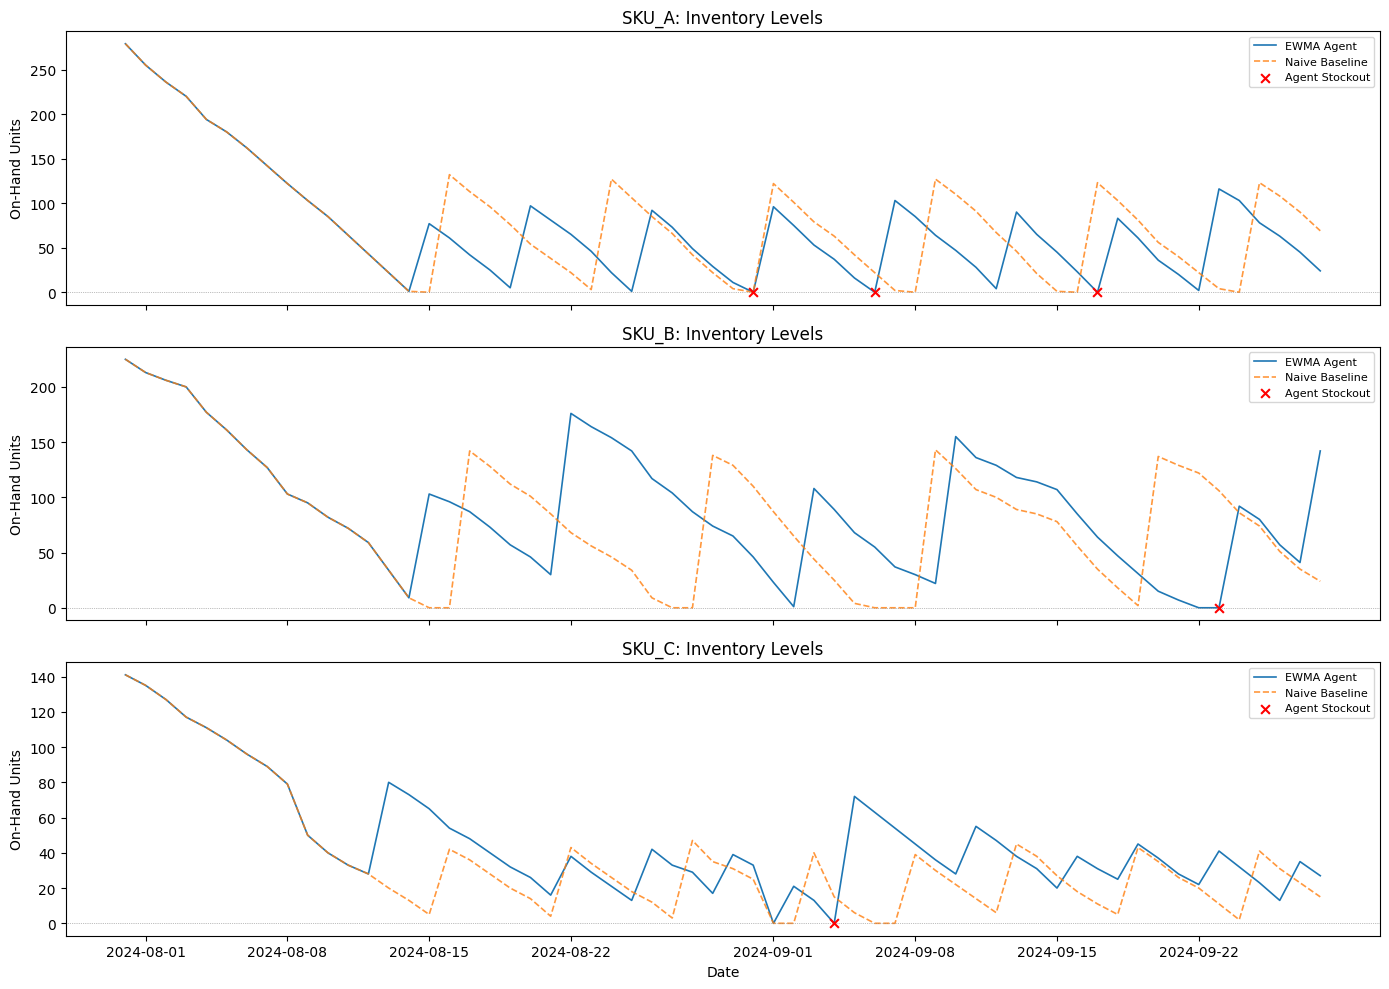

In [18]:
# --------------------------------------------------------------------------
# 9b. Visualization: On-hand inventory over time, Agent vs Baseline
# --------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, sku in zip(axes, ['SKU_A', 'SKU_B', 'SKU_C']):
    agent_log = agent_results[sku]['log']
    bl_log = baseline_results[sku]['log']

    ax.plot(agent_log['date'], agent_log['on_hand'], label='EWMA Agent', linewidth=1.2)
    ax.plot(bl_log['date'], bl_log['on_hand'], label='Naive Baseline',
            linewidth=1.2, linestyle='--', alpha=0.8)

    # Mark stockout days for agent
    stockout_mask = agent_log['unfulfilled'] > 0
    if stockout_mask.any():
        ax.scatter(agent_log.loc[stockout_mask, 'date'],
                   agent_log.loc[stockout_mask, 'on_hand'],
                   color='red', marker='x', s=40, label='Agent Stockout', zorder=5)

    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle=':')
    ax.set_ylabel('On-Hand Units')
    ax.set_title(f'{sku}: Inventory Levels')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

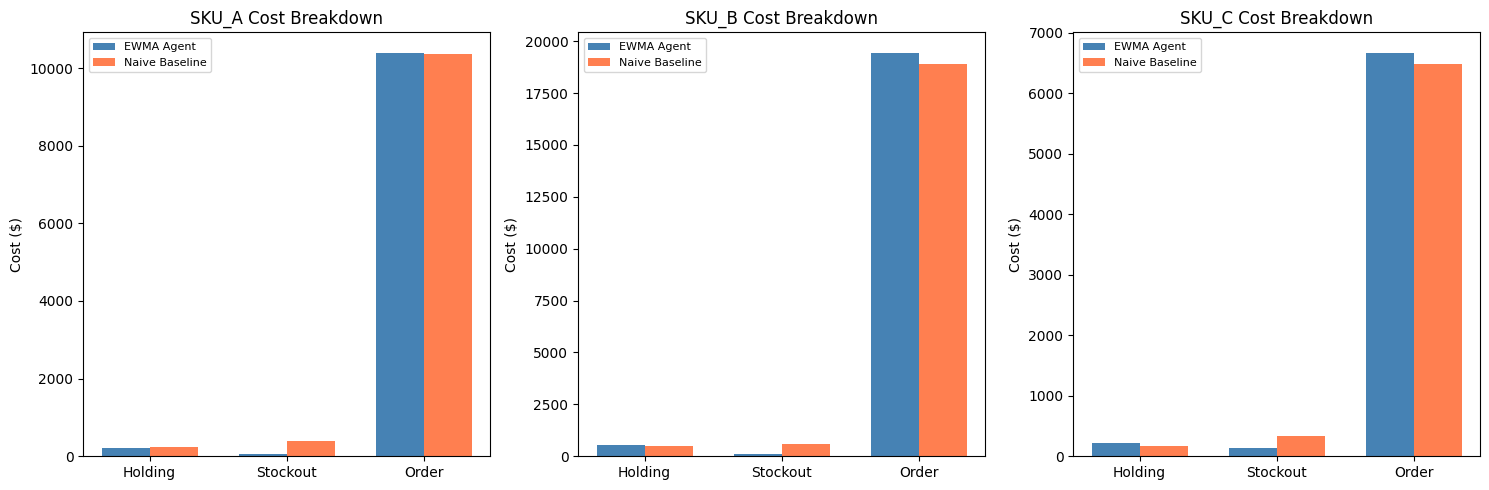

In [19]:
# --------------------------------------------------------------------------
# 9c. Cost breakdown bar chart: Agent vs Baseline per SKU
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cost_types = ['total_holding_cost', 'total_stockout_cost', 'total_order_cost']
cost_labels = ['Holding', 'Stockout', 'Order']
bar_width = 0.35

for ax, sku in zip(axes, ['SKU_A', 'SKU_B', 'SKU_C']):
    ak = agent_results[sku]['kpis']
    bk = baseline_results[sku]['kpis']

    agent_costs = [ak[c] for c in cost_types]
    bl_costs = [bk[c] for c in cost_types]

    x = np.arange(len(cost_labels))
    ax.bar(x - bar_width/2, agent_costs, bar_width, label='EWMA Agent', color='steelblue')
    ax.bar(x + bar_width/2, bl_costs, bar_width, label='Naive Baseline', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(cost_labels)
    ax.set_ylabel('Cost ($)')
    ax.set_title(f'{sku} Cost Breakdown')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Trade-off Reflection

**Rubric: Trade-off Reflection (1 pt)** - Brief explanation of inventory vs service trade-offs.

### Inventory vs. Service Level Trade-offs

The fundamental tension in inventory management is between **holding too much stock** (high carrying costs, tied-up capital) and **holding too little** (stockouts, lost sales, damaged customer trust).

**What the simulation shows:**

- **SKU_A (steady demand):** Both strategies perform reasonably well because demand is predictable. The EWMA agent's advantage is modest since there is little volatility to adapt to. The main savings come from more precise order sizing rather than reactive ordering.

- **SKU_B (seasonal/weekly cycle):** The EWMA agent captures the weekly demand pattern and adjusts forecasts accordingly. The naive baseline, using a flat average, tends to either over-order during low-demand periods (wasting holding costs) or under-order during peak periods (causing stockouts).

- **SKU_C (spiky/promotional):** This is where the trade-off is most visible. The high stockout cost ($12/unit) means missing demand is expensive. The EWMA agent with safety stock buffers against spikes, but can't perfectly predict random promotions. The higher service level (0.95) means carrying more safety stock, which increases holding costs but protects against the much higher stockout penalties.

**Key takeaway:** There is no single "right" answer. A higher service level reduces stockout risk but increases inventory investment. The agent's value is in making this trade-off dynamically and transparently, rather than relying on fixed rules that ignore changing demand patterns.